In [1]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import pyvista as pv
import nest_asyncio

nest_asyncio.apply()

pv.set_jupyter_backend('trame')

from pyvista.trame.jupyter import launch_server
await launch_server().ready

from Suspension.hardpoint_loader import load_suspension_params
from Suspension.jax_solvers import solve_and_measure_corner
from Suspension.visualizer import SuspensionVisualizer

1.0
0.9999998
0.9999998
0.99999964
1.0000001
1.0000005
1.0000006
0.9999997
1.0000001
1.0
0.99999946
0.99999976
0.9999999
1.0
0.9999995
0.9999997
1.0000002
0.99999976
0.99999976
1.0
1.0000002
1.0000001
1.0000002
1.0000006
1.0000001
1.0000006
1.0000007
0.9999997
1.0000001
1.0000001
1.0000004
1.0000001
1.0
0.99999964
1.0000001
0.9999997
0.9999996
0.99999964
1.0000004
0.9999998


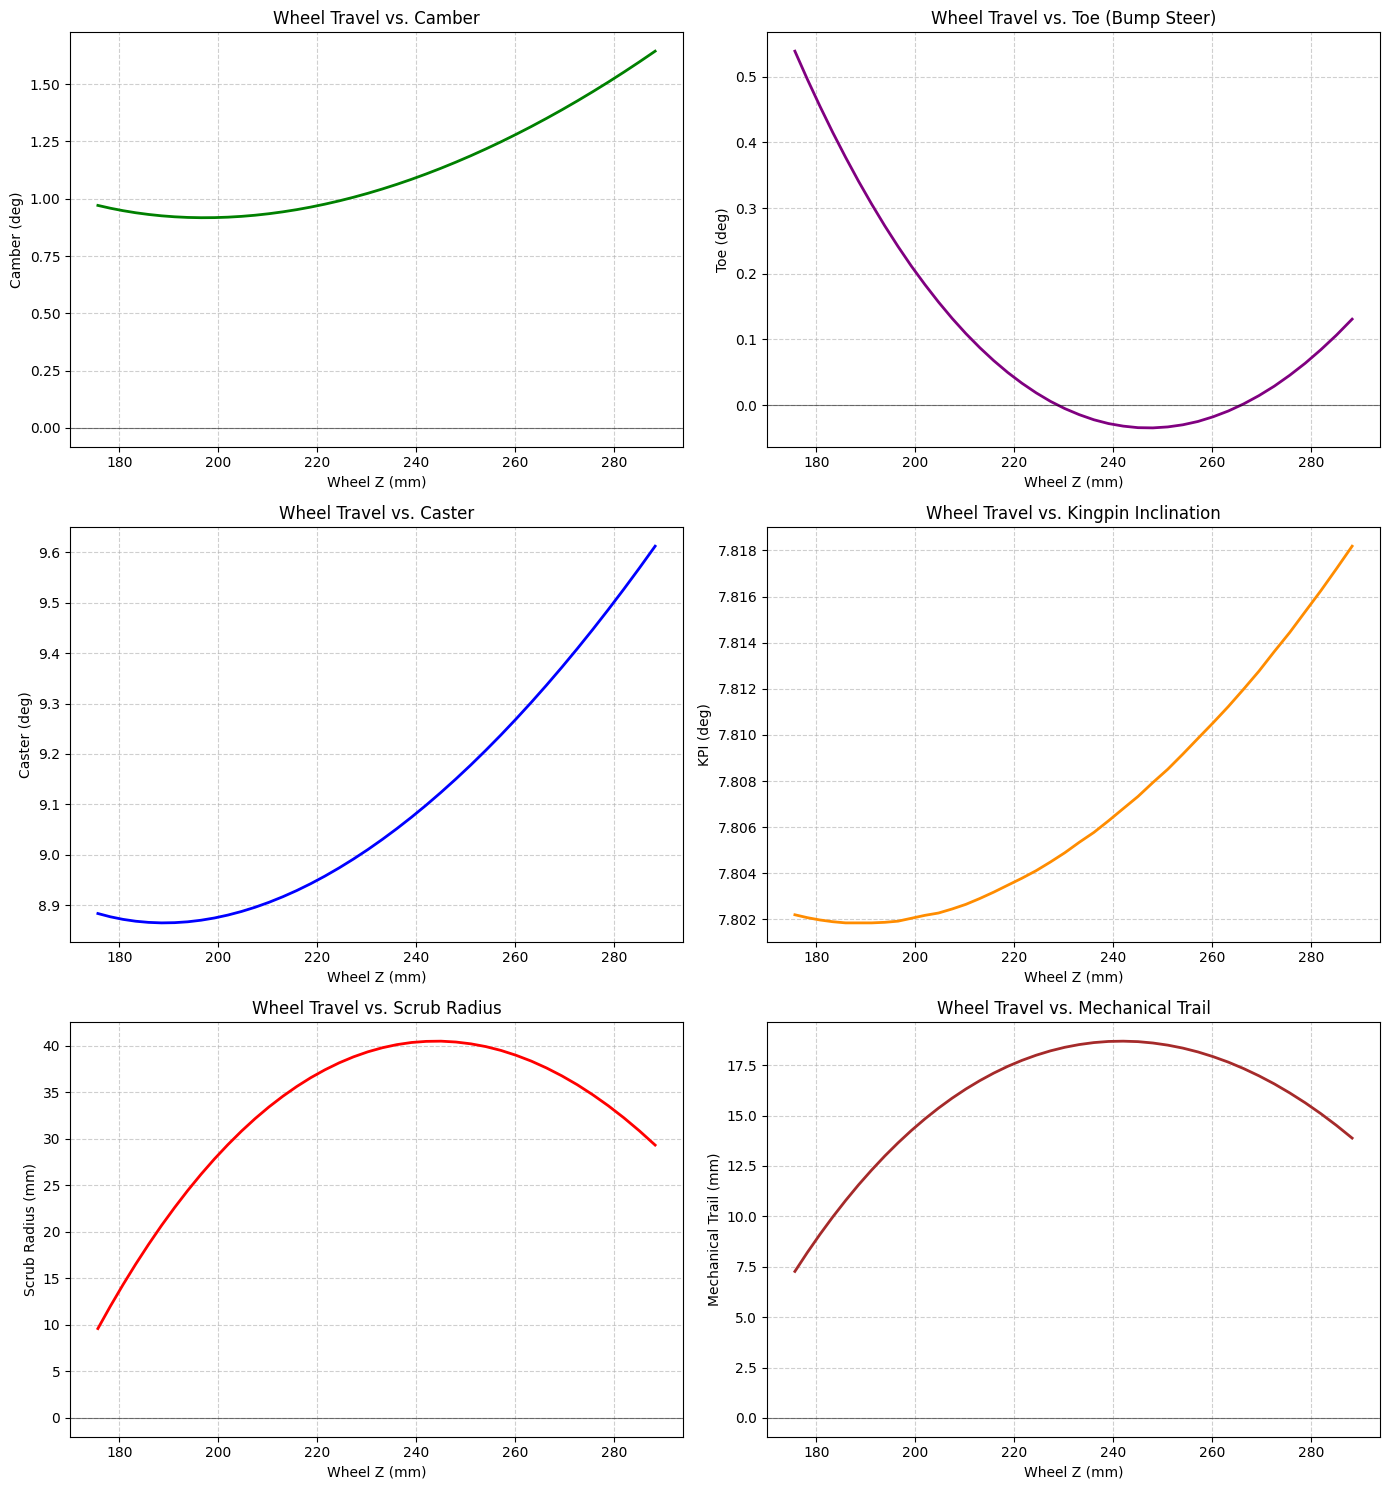

In [2]:
# 1. Setup Parameters
corner_name = "front_right"
params = load_suspension_params("hardpoints.yaml", corner_name)

# 2. Define the Range of Motion
thetas = jnp.radians(jnp.linspace(-10, 10, 40)) 
fixed_steer = 0.0

# 3. Initialize storage for results
travel_mm = []
caster_deg = []
scrub_mm = []
camber_deg = []
toe_deg = []
kpi_deg = []          # New: Kingpin Inclination
mech_trail_mm = []    # New: Mechanical Trail

# 4. Run the Sweep Loop
for t in thetas:
    metrics = solve_and_measure_corner(t, fixed_steer, params)
    
    # Store the values (converting to readable units)
    travel_mm.append(metrics["wheel_z"] * 1000)
    caster_deg.append(jnp.degrees(metrics["caster"]))
    scrub_mm.append(metrics["scrub_radius"] * 1000)
    camber_deg.append(jnp.degrees(metrics["camber"]))
    toe_deg.append(jnp.degrees(metrics["toe"]))
    kpi_deg.append(jnp.degrees(metrics["kingpin_inc"]))
    mech_trail_mm.append(metrics["mechanical_trail"] * 1000)

# 5. Plotting (Expanded to 3x2 Grid)
plt.figure(figsize=(14, 15))

# Plot 1: Camber Curve
plt.subplot(3, 2, 1)
plt.plot(travel_mm, camber_deg, color='green', linewidth=2)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)
plt.title("Wheel Travel vs. Camber")
plt.xlabel("Wheel Z (mm)")
plt.ylabel("Camber (deg)")
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Bump Steer (Toe)
plt.subplot(3, 2, 2)
plt.plot(travel_mm, toe_deg, color='purple', linewidth=2)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)
plt.title("Wheel Travel vs. Toe (Bump Steer)")
plt.xlabel("Wheel Z (mm)")
plt.ylabel("Toe (deg)")
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 3: Caster
plt.subplot(3, 2, 3)
plt.plot(travel_mm, caster_deg, color='blue', linewidth=2)
plt.title("Wheel Travel vs. Caster")
plt.xlabel("Wheel Z (mm)")
plt.ylabel("Caster (deg)")
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 4: Kingpin Inclination (KPI/SAI)
plt.subplot(3, 2, 4)
plt.plot(travel_mm, kpi_deg, color='darkorange', linewidth=2)
plt.title("Wheel Travel vs. Kingpin Inclination")
plt.xlabel("Wheel Z (mm)")
plt.ylabel("KPI (deg)")
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 5: Scrub Radius
plt.subplot(3, 2, 5)
plt.plot(travel_mm, scrub_mm, color='red', linewidth=2)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)
plt.title("Wheel Travel vs. Scrub Radius")
plt.xlabel("Wheel Z (mm)")
plt.ylabel("Scrub Radius (mm)")
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 6: Mechanical Trail
plt.subplot(3, 2, 6)
plt.plot(travel_mm, mech_trail_mm, color='brown', linewidth=2)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)
plt.title("Wheel Travel vs. Mechanical Trail")
plt.xlabel("Wheel Z (mm)")
plt.ylabel("Mechanical Trail (mm)")
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [3]:
# 1. Setup the parameters (All 4 corners)
params_fr = load_suspension_params("hardpoints.yaml", "front_right")
params_fl = load_suspension_params("hardpoints.yaml", "front_left")
params_rr = load_suspension_params("hardpoints.yaml", "rear_right")
params_rl = load_suspension_params("hardpoints.yaml", "rear_left")

# 2. Initialize Visualizer
viz = SuspensionVisualizer(params_fr)

# 3. Build the environment (Chassis points for all 4 corners)
viz.add_ground_plane()
for p in [params_fr, params_fl, params_rr, params_rl]:
    viz.add_chassis_points(p)

# 4. Solve Initial States
corners = [
    ("fr", params_fr), ("fl", params_fl),
    ("rr", params_rr), ("rl", params_rl)
]

initial_states = {}
for name, p in corners:
    initial_states[name] = solve_and_measure_corner(0.0, 0.01, p)
    # Setup ICs for each corner
    viz.setup_instant_center(
        initial_states[name]["instant_roll_center"], 
        initial_states[name]["contact_patch"], 
        f"ic_{name}"
    )
    # viz.setup_pitch_center(initial_states[name]["instant_pitch_center"], initial_states[name]["contact_patch"], f"pic_{name}")
    viz.setup_isa_axis(initial_states[name]["isa_q"], initial_states[name]["isa_s"], f"isa_{name}")

# 5. Setup the moving parts for all 4 corners
for name, p in corners:
    state = initial_states[name]
    
    # Define colors: Blue/Red for Front, Cyan/Orange for Rear (optional distinction)
    u_color = "royalblue" if "f" in name else "darkcyan"
    l_color = "firebrick" if "f" in name else "chocolate"

    # A-Arms
    viz.setup_a_arms(p["u_front"], p["u_rear"], state["upper_bj"], u_color, f"u_arm_{name}")
    viz.setup_a_arms(p["l_front"], p["l_rear"], state["lower_bj"], l_color, f"l_arm_{name}")

    # Hardpoints
    viz.setup_hardpoints(state["upper_bj"], f"UBJ_{name}")
    viz.setup_hardpoints(state["lower_bj"], f"LBJ_{name}")
    viz.setup_hardpoints(state["toe_link"], f"TOE_{name}")

    # Upright
    viz.setup_upright(state["upper_bj"], state["lower_bj"], state["toe_link"], "green", f"upright_{name}")

    # Tie Rod and Wheel
    viz.setup_tie_rod(p["rack_origin"], state["toe_link"], f"tie_rod_{name}")
    viz.setup_wheel_disc(state["wheel_center"], state["axle_dir"], p["wheel_radius"], 0.2, f"wheel_{name}")

# 6. Preview the full car
viz.plotter.reset_camera()
# Position camera to see the whole car
viz.plotter.camera_position = [(5, -5, 2), (1, 0, 0.5), (0, 0, 1)] 
viz.plotter.show()

0.9999999
1.0000001
0.9999996
1.0000004


Widget(value='<iframe src="http://localhost:58611/index.html?ui=P_0x1441d9710_0&reconnect=auto" class="pyvista…

In [4]:
# # 1. Setup the Scene
# viz = SuspensionVisualizer(params_r)
# viz.add_ground_plane()
# viz.add_chassis_points(params_r)
# viz.add_chassis_points(params_l)

# # Initialize all meshes at static height (theta=0)
# for side, p, state in [("r", params_r, initial_state_r), ("l", params_l, initial_state_l)]:
#     viz.setup_a_arms(p["u_front"], p["u_rear"], state["upper_bj"], "royalblue", f"u_arm_{side}")
#     viz.setup_a_arms(p["l_front"], p["l_rear"], state["lower_bj"], "firebrick", f"l_arm_{side}")
#     viz.setup_hardpoints(state["upper_bj"], f"UBJ_{side}")
#     viz.setup_hardpoints(state["lower_bj"], f"LBJ_{side}")
#     viz.setup_hardpoints(state["toe_link"], f"TOE_{side}")
#     viz.setup_upright(state["upper_bj"], state["lower_bj"], state["toe_link"], "green", f"upright_{side}")
#     viz.setup_tie_rod(p["rack_origin"], state["toe_link"], f"tie_rod_{side}")
#     viz.setup_wheel_disc(state["wheel_center"], state["axle_dir"], p["wheel_radius"], 0.2, f"wheel_{side}")

# # 2. Define Animation Parameters
# frames = 60
# # Create a sine wave for theta: -10 degrees to +10 degrees
# theta_sweep = jnp.radians(10) * jnp.sin(jnp.linspace(0, 2 * jnp.pi, frames))

# # 3. Run the Animation Loop
# filename = "suspension_animation.mp4"
# viz.plotter.open_movie(filename)

# for t in theta_sweep:
#     # Solve new states for both sides
#     state_r = solve_corner_jax(t, 0.0, params_r)
#     state_l = solve_corner_jax(t, 0.0, params_l)
    
#     for side, p, state in [("r", params_r, state_r), ("l", params_l, state_l)]:
#         # Update A-Arms
#         viz.update_wishbone(f"u_arm_{side}", p["u_front"], p["u_rear"], state["upper_bj"])
#         viz.update_wishbone(f"l_arm_{side}", p["l_front"], p["l_rear"], state["lower_bj"])
        
#         # Update Upright and Hardpoints
#         viz.update_upright(f"upright_{side}", state["upper_bj"], state["lower_bj"], state["toe_link"])
#         viz.update_hardpoint(f"UBJ_{side}", state["upper_bj"])
#         viz.update_hardpoint(f"LBJ_{side}", state["lower_bj"])
#         viz.update_hardpoint(f"TOE_{side}", state["toe_link"])
        
#         # Update Tie Rod and Wheel
#         viz.update_tie_rod(f"tie_rod_{side}", p["rack_origin"], state["toe_link"])
#         viz.update_wheel(f"wheel_{side}", state["wheel_center"], state["axle_dir"], p["wheel_radius"], 0.2)
    
#     viz.plotter.write_frame()

# viz.plotter.close()
# print(f"Animation saved as {filename}")